# Detecció de danys en vehicles — Comparació de models
Pipeline complet: preprocessament → entrenament → avaluació → comparació (CustomCNN · AlexNet · ResNet-18 · ResNet-50) → localització de danys.

In [3]:
!pip install torch torchvision 
!pip install scikit-learn matplotlib pillow 
!pip install ultralytics 

## 0. Imports i configuració

In [4]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Configuració ──────────────────────────────────────────────────────────────
TRAIN_DIR   = Path('train')
TEST_DIR    = Path('test')
OUTPUT_DIR  = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

CLASSES     = {'00-damage': 'Danyat', '01-whole': 'Sencer'}
CLASS_NAMES = ['00-damage', '01-whole']
IMG_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
COLORS      = {'Danyat': '#e74c3c', 'Sencer': '#2ecc71'}

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 2
EPOCHS      = 8
LR          = 1e-4
VAL_SPLIT   = 0.2
PATIENCE    = 3
YOLO_SAMPLES = 10
SKIP_YOLO    = False   # canvia a True si no tens ultralytics instal·lat

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositiu: {device}')

Dispositiu: cpu


## 1. Preprocessament — validació i estadístiques del dataset

In [5]:
def check_images(split_dir):
    stats = defaultdict(lambda: {'ok': 0, 'error': 0, 'paths': []})
    for folder_name, label in CLASSES.items():
        folder = split_dir / folder_name
        if not folder.exists():
            print(f'[AVÍS] Carpeta no trobada: {folder}')
            continue
        for p in folder.iterdir():
            if p.suffix.lower() not in IMG_EXTS:
                continue
            try:
                Image.open(p).verify()
                stats[label]['ok'] += 1
                stats[label]['paths'].append(p)
            except Exception as e:
                stats[label]['error'] += 1
                print(f'[ERROR] {p.name}: {e}')
    return stats

all_stats = {}
for split_name, split_dir in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    stats = check_images(split_dir)
    all_stats[split_name] = stats
    print(f'\n── {split_name.upper()} ──')
    for label, info in stats.items():
        print(f'  {label:8s}: {info["ok"]:4d} OK  |  {info["error"]} errors')


── TRAIN ──
  Danyat  :  920 OK  |  0 errors
  Sencer  :  920 OK  |  0 errors

── TEST ──
  Danyat  :  230 OK  |  0 errors
  Sencer  :  230 OK  |  0 errors


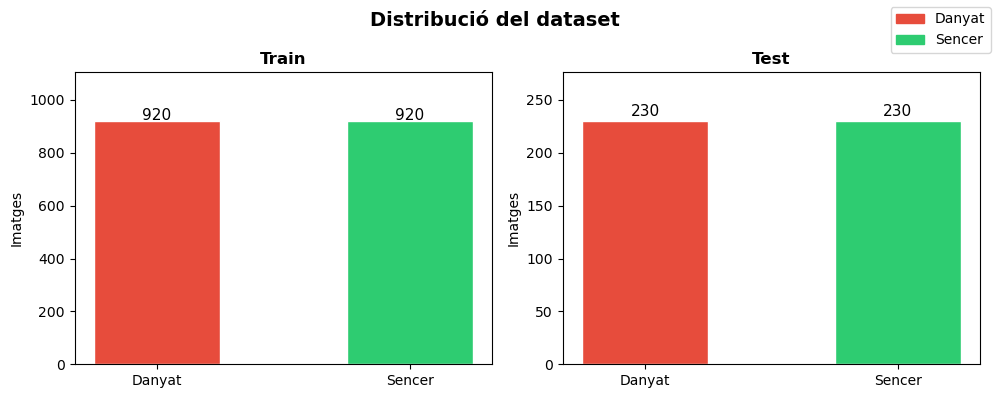

In [6]:
# Distribució de classes
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_name, stats) in zip(axes, all_stats.items()):
    labels = list(stats.keys())
    counts = [stats[l]['ok'] for l in labels]
    bars = ax.bar(labels, counts,
                  color=[COLORS.get(l, '#95a5a6') for l in labels],
                  edgecolor='white', width=0.5)
    ax.set_title(split_name.capitalize(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Imatges')
    ax.set_ylim(0, max(counts) * 1.2)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(c), ha='center', fontsize=11)
fig.legend(handles=[mpatches.Patch(color=c, label=l) for l, c in COLORS.items()],
           loc='upper right')
fig.suptitle('Distribució del dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dataset_distribution.png', dpi=150)
plt.show()

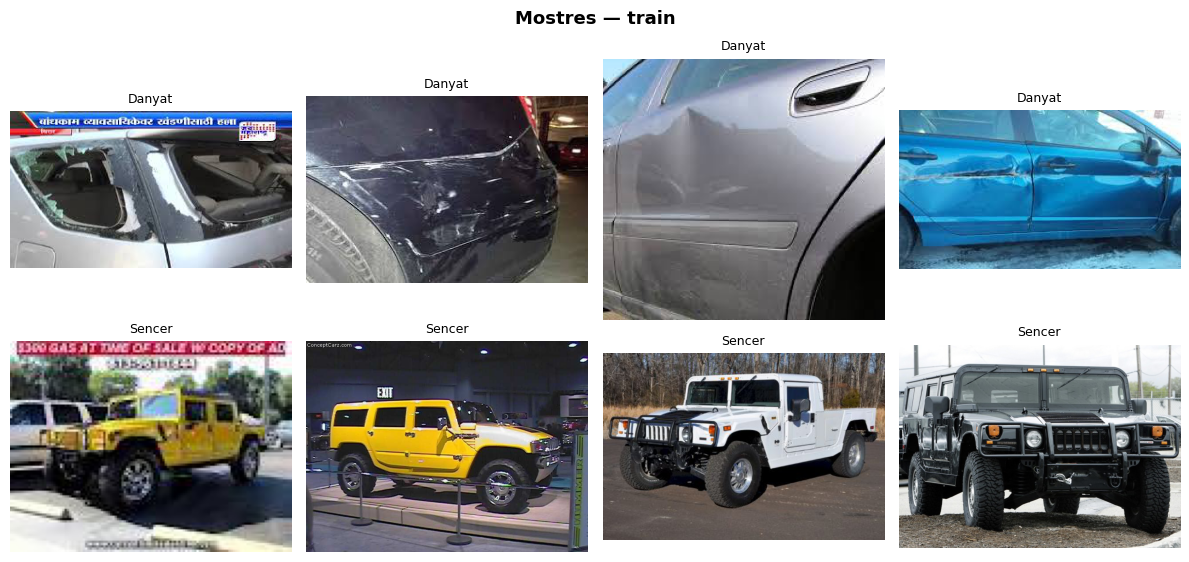

In [7]:
# Mostres visuals del train
n = 4
train_stats = all_stats['train']
fig, axes = plt.subplots(len(train_stats), n, figsize=(3*n, 3*len(train_stats)))
for row, (label, info) in enumerate(train_stats.items()):
    for col in range(n):
        ax = axes[row][col]
        if col < len(info['paths']):
            ax.imshow(Image.open(info['paths'][col]).convert('RGB'))
            ax.set_title(label, fontsize=9)
        ax.axis('off')
plt.suptitle('Mostres — train', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Avís desequilibri
counts = [v['ok'] for v in train_stats.values()]
if len(counts) == 2 and min(counts) > 0 and max(counts)/min(counts) > 1.5:
    print(f'[AVÍS] Desequilibri entre classes (ratio {max(counts)/min(counts):.2f}x).')

## 2. Entrenament — ResNet-50 amb transfer learning

In [8]:
# Transformacions
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(), normalize,
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), normalize,
])

# Dataloaders
full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
test_ds    = datasets.ImageFolder(TEST_DIR,  transform=val_tf)

val_size   = int(len(full_train) * VAL_SPLIT)
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(full_train, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))
val_ds.dataset.transform = val_tf

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Classes: {full_train.classes}')
print(f'Train: {train_size} | Val: {val_size} | Test: {len(test_ds)}')

Classes: ['00-damage', '01-whole']
Train: 1472 | Val: 368 | Test: 460


In [9]:
# Model: ResNet-50 preentrenat, només entrenem la capa final
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for name, p in model.named_parameters():
    if 'fc' not in name:
        p.requires_grad = False
model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(model.fc.in_features, NUM_CLASSES))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train: loss.backward(); optimizer.step()
            loss_sum += loss.item() * imgs.size(0)
            correct  += out.max(1)[1].eq(labels).sum().item()
            total    += imgs.size(0)
    return loss_sum/total, correct/total

In [10]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_acc, no_improve = 0.0, 0
model_path = OUTPUT_DIR / 'best_resnet50.pth'

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc]):
        history[k].append(v)

    if vl_acc > best_acc:
        best_acc, no_improve = vl_acc, 0
        torch.save(model.state_dict(), model_path)
        flag = ' ← millor'
    else:
        no_improve += 1
        flag = ''

    print(f'Època {epoch:02d}/{EPOCHS}  '
          f'loss {tr_loss:.4f}/{vl_loss:.4f}  '
          f'acc {tr_acc*100:.1f}%/{vl_acc*100:.1f}%{flag}')

    if no_improve >= PATIENCE:
        print(f'Early stopping ({PATIENCE} èpoques sense millora).')
        break

print(f'\nMillor val_acc: {best_acc*100:.1f}%')

Època 01/8  loss 0.6315/0.5620  acc 69.5%/86.1% ← millor
Època 02/8  loss 0.5418/0.4871  acc 84.6%/89.7% ← millor
Època 03/8  loss 0.4865/0.4378  acc 86.5%/90.8% ← millor
Època 04/8  loss 0.4374/0.3973  acc 86.4%/90.8%
Època 05/8  loss 0.4083/0.3664  acc 88.2%/90.8%
Època 06/8  loss 0.3845/0.3540  acc 88.6%/90.8%
Early stopping (3 èpoques sense millora).

Millor val_acc: 90.8%


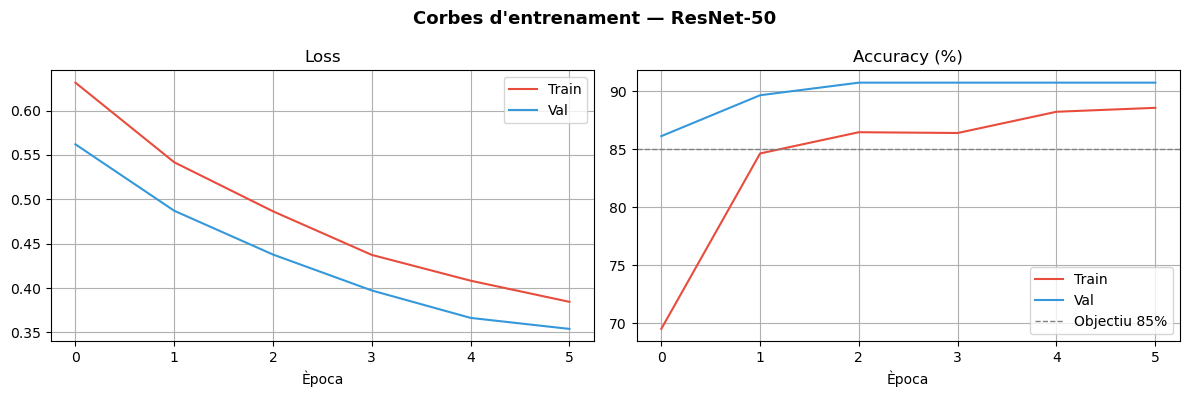

In [11]:
# Corbes d'entrenament
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Train', color='#e74c3c')
ax1.plot(history['val_loss'],   label='Val',   color='#3498db')
ax1.set_title('Loss'); ax1.set_xlabel('Època'); ax1.legend(); ax1.grid(True)

ax2.plot([a*100 for a in history['train_acc']], label='Train', color='#e74c3c')
ax2.plot([a*100 for a in history['val_acc']],   label='Val',   color='#3498db')
ax2.axhline(85, color='gray', linestyle='--', linewidth=1, label='Objectiu 85%')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Època'); ax2.legend(); ax2.grid(True)

plt.suptitle('Corbes d\'entrenament — ResNet-50', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150)
plt.show()

## 3. Avaluació — matriu de confusió i mètriques

In [12]:
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).max(1)[1]
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = (all_labels == all_preds).mean() * 100
print(f'Test accuracy: {acc:.2f}%\n')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Test accuracy: 93.04%

              precision    recall  f1-score   support

   00-damage       0.92      0.94      0.93       230
    01-whole       0.94      0.92      0.93       230

    accuracy                           0.93       460
   macro avg       0.93      0.93      0.93       460
weighted avg       0.93      0.93      0.93       460



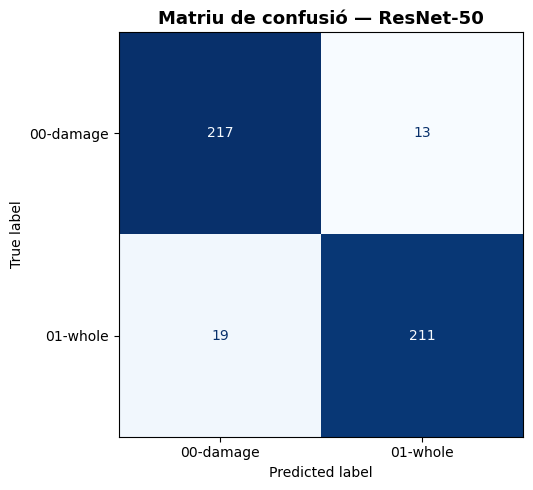

Imatges classificades com a danyades: 236


In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(all_labels, all_preds),
                       display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriu de confusió — ResNet-50', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

damage_idx    = test_ds.class_to_idx['00-damage']
damaged_paths = [Path(test_ds.samples[i][0]) for i in range(len(test_ds)) if all_preds[i] == damage_idx]
print(f'Imatges classificades com a danyades: {len(damaged_paths)}')

In [ ]:
# Guardem resultats del ResNet-50 al diccionari de comparació
from sklearn.metrics import precision_score, recall_score, f1_score

results_dict = {}
results_dict['ResNet-50'] = {
    'preds':   all_preds.copy(),
    'labels':  all_labels.copy(),
    'acc':     acc,
    'history': {k: list(v) for k, v in history.items()},
}
print('Resultats ResNet-50 guardats.')

## 5. Comparació de models: CustomCNN · AlexNet · ResNet-18 · ResNet-50

Entrena els tres models alternatius amb la mateixa configuració (transfer learning
per AlexNet i ResNet-18; entrenament des de zero per a la CNN pròpia) i compara
els resultats en un taula i un gràfic de barres.

In [ ]:
# ── Definicions de models i funció d'entrenament genèrica ────────────────────

class CustomCNN(nn.Module):
    """2 capes conv + 2 capes fully-connected."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        flat = 64 * (IMG_SIZE // 4) * (IMG_SIZE // 4)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, NUM_CLASSES),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


def build_model(name: str) -> nn.Module:
    """Construeix i retorna el model indicat, amb pesos preentrenats si s'escau."""
    if name == 'CustomCNN':
        return CustomCNN().to(device)

    elif name == 'AlexNet':
        m = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        for p in m.parameters(): p.requires_grad = False
        m.classifier[6] = nn.Linear(4096, NUM_CLASSES)
        return m.to(device)

    elif name == 'ResNet-18':
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        for n_, p in m.named_parameters():
            if 'fc' not in n_: p.requires_grad = False
        m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, NUM_CLASSES))
        return m.to(device)

    else:
        raise ValueError(f'Model desconegut: {name}')


def train_and_eval(model_name: str, epochs: int = EPOCHS) -> dict:
    """Entrena model_name i retorna preds, labels, acc i historial."""
    m     = build_model(model_name)
    crit  = nn.CrossEntropyLoss()
    opt   = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=LR)
    sched = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
    path  = OUTPUT_DIR / f'best_{model_name.lower().replace("-","")}.pth'

    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_va, no_imp = 0.0, 0

    for ep in range(1, epochs + 1):
        # — Train —
        m.train()
        tl, tc, tt = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad()
            out  = m(imgs); loss = crit(out, lbls)
            loss.backward(); opt.step()
            tl += loss.item() * imgs.size(0)
            tc += out.max(1)[1].eq(lbls).sum().item()
            tt += imgs.size(0)

        # — Val —
        m.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out  = m(imgs); loss = crit(out, lbls)
                vl += loss.item() * imgs.size(0)
                vc += out.max(1)[1].eq(lbls).sum().item()
                vt += imgs.size(0)
        sched.step()

        ta, va = tc / tt, vc / vt
        for k, v in zip(hist, [tl/tt, vl/vt, ta, va]):
            hist[k].append(v)

        if va > best_va:
            best_va, no_imp = va, 0
            torch.save(m.state_dict(), path)
            flag = ' ← millor'
        else:
            no_imp += 1
            flag = ''

        print(f'[{model_name}] Època {ep:02d}/{epochs}  '
              f'acc {ta*100:.1f}%/{va*100:.1f}%{flag}')

        if no_imp >= PATIENCE:
            print(f'  Early stopping.')
            break

    # — Test —
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    preds_, lbls_ = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            p_ = m(imgs.to(device)).max(1)[1]
            preds_.extend(p_.cpu().numpy())
            lbls_.extend(lbls.numpy())

    preds_ = np.array(preds_); lbls_ = np.array(lbls_)
    test_acc = (lbls_ == preds_).mean() * 100
    print(f'\n[{model_name}] Test accuracy: {test_acc:.2f}%\n')
    return {'preds': preds_, 'labels': lbls_, 'acc': test_acc, 'history': hist}

In [ ]:
# ── Entrenament dels tres models alternatius ─────────────────────────────────
for mname in ['CustomCNN', 'AlexNet', 'ResNet-18']:
    print(f'\n{"="*55}')
    print(f'  Entrenant: {mname}')
    print(f'{"="*55}')
    results_dict[mname] = train_and_eval(mname)

In [ ]:
# ── Taula de comparació ───────────────────────────────────────────────────────
import pandas as pd

MODEL_DISPLAY = {
    'CustomCNN': 'Nostra (2CNN+2FC)',
    'AlexNet':   'AlexNet',
    'ResNet-18': 'ResNet-18',
    'ResNet-50': 'ResNet-50',
}
ORDER = ['CustomCNN', 'AlexNet', 'ResNet-18', 'ResNet-50']

rows = []
for k in ORDER:
    if k not in results_dict:
        continue
    r  = results_dict[k]
    pr = precision_score(r['labels'], r['preds'], average='weighted', zero_division=0)
    rc = recall_score   (r['labels'], r['preds'], average='weighted', zero_division=0)
    f1 = f1_score       (r['labels'], r['preds'], average='weighted', zero_division=0)
    bv = max(r['history']['val_acc']) * 100
    rows.append({
        'Model':            MODEL_DISPLAY[k],
        'Val Acc màx (%)':  f'{bv:.2f}',
        'Test Acc (%)':     f'{r["acc"]:.2f}',
        'Precisió':         f'{pr:.4f}',
        'Recall':           f'{rc:.4f}',
        'F1-score':         f'{f1:.4f}',
    })

df_comp = pd.DataFrame(rows)
print('\n' + '='*65)
print('  TAULA COMPARATIVA DE MODELS')
print('='*65)
print(df_comp.to_string(index=False))
print('='*65)
df_comp.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
print('\nGuardat a outputs/model_comparison.csv')

In [ ]:
# ── Gràfic de barres — Test Accuracy ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = [r['Model']          for r in rows]
test_accs   = [float(r['Test Acc (%)']) for r in rows]
val_accs    = [float(r['Val Acc màx (%)']) for r in rows]
f1_scores   = [float(r['F1-score']) for r in rows]
colors_bar  = ['#9b59b6', '#f39c12', '#3498db', '#e74c3c']

# — Test accuracy —
ax = axes[0]
bars = ax.bar(model_names, test_accs, color=colors_bar, edgecolor='white', width=0.55)
ax.set_ylim(0, 108)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy per model', fontsize=12, fontweight='bold')
for bar, val in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# — F1-score —
ax2 = axes[1]
bars2 = ax2.bar(model_names, f1_scores, color=colors_bar, edgecolor='white', width=0.55)
ax2.set_ylim(0, 1.10)
ax2.set_ylabel('F1-score (weighted)')
ax2.set_title('F1-score per model', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Comparació de models — Detecció de danys en vehicles',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_chart.png', dpi=150)
plt.show()

In [ ]:
# ── Corbes d'entrenament de tots els models ───────────────────────────────────
ORDER_PLOT = ['CustomCNN', 'AlexNet', 'ResNet-18', 'ResNet-50']
COLORS_PLOT = ['#9b59b6', '#f39c12', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for mname, col in zip(ORDER_PLOT, COLORS_PLOT):
    if mname not in results_dict: continue
    h = results_dict[mname]['history']
    axes[0].plot(h['val_loss'],           label=MODEL_DISPLAY[mname], color=col)
    axes[1].plot([a*100 for a in h['val_acc']], label=MODEL_DISPLAY[mname], color=col)

axes[0].set_title('Val Loss');     axes[0].set_xlabel('Època'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy (%)'); axes[1].set_xlabel('Època'); axes[1].legend(); axes[1].grid(True)
axes[1].axhline(85, color='gray', linestyle='--', linewidth=1, label='Objectiu 85%')

plt.suptitle('Corbes de validació — tots els models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_models_curves.png', dpi=150)
plt.show()

## 4. Localització de danys — YOLOv8

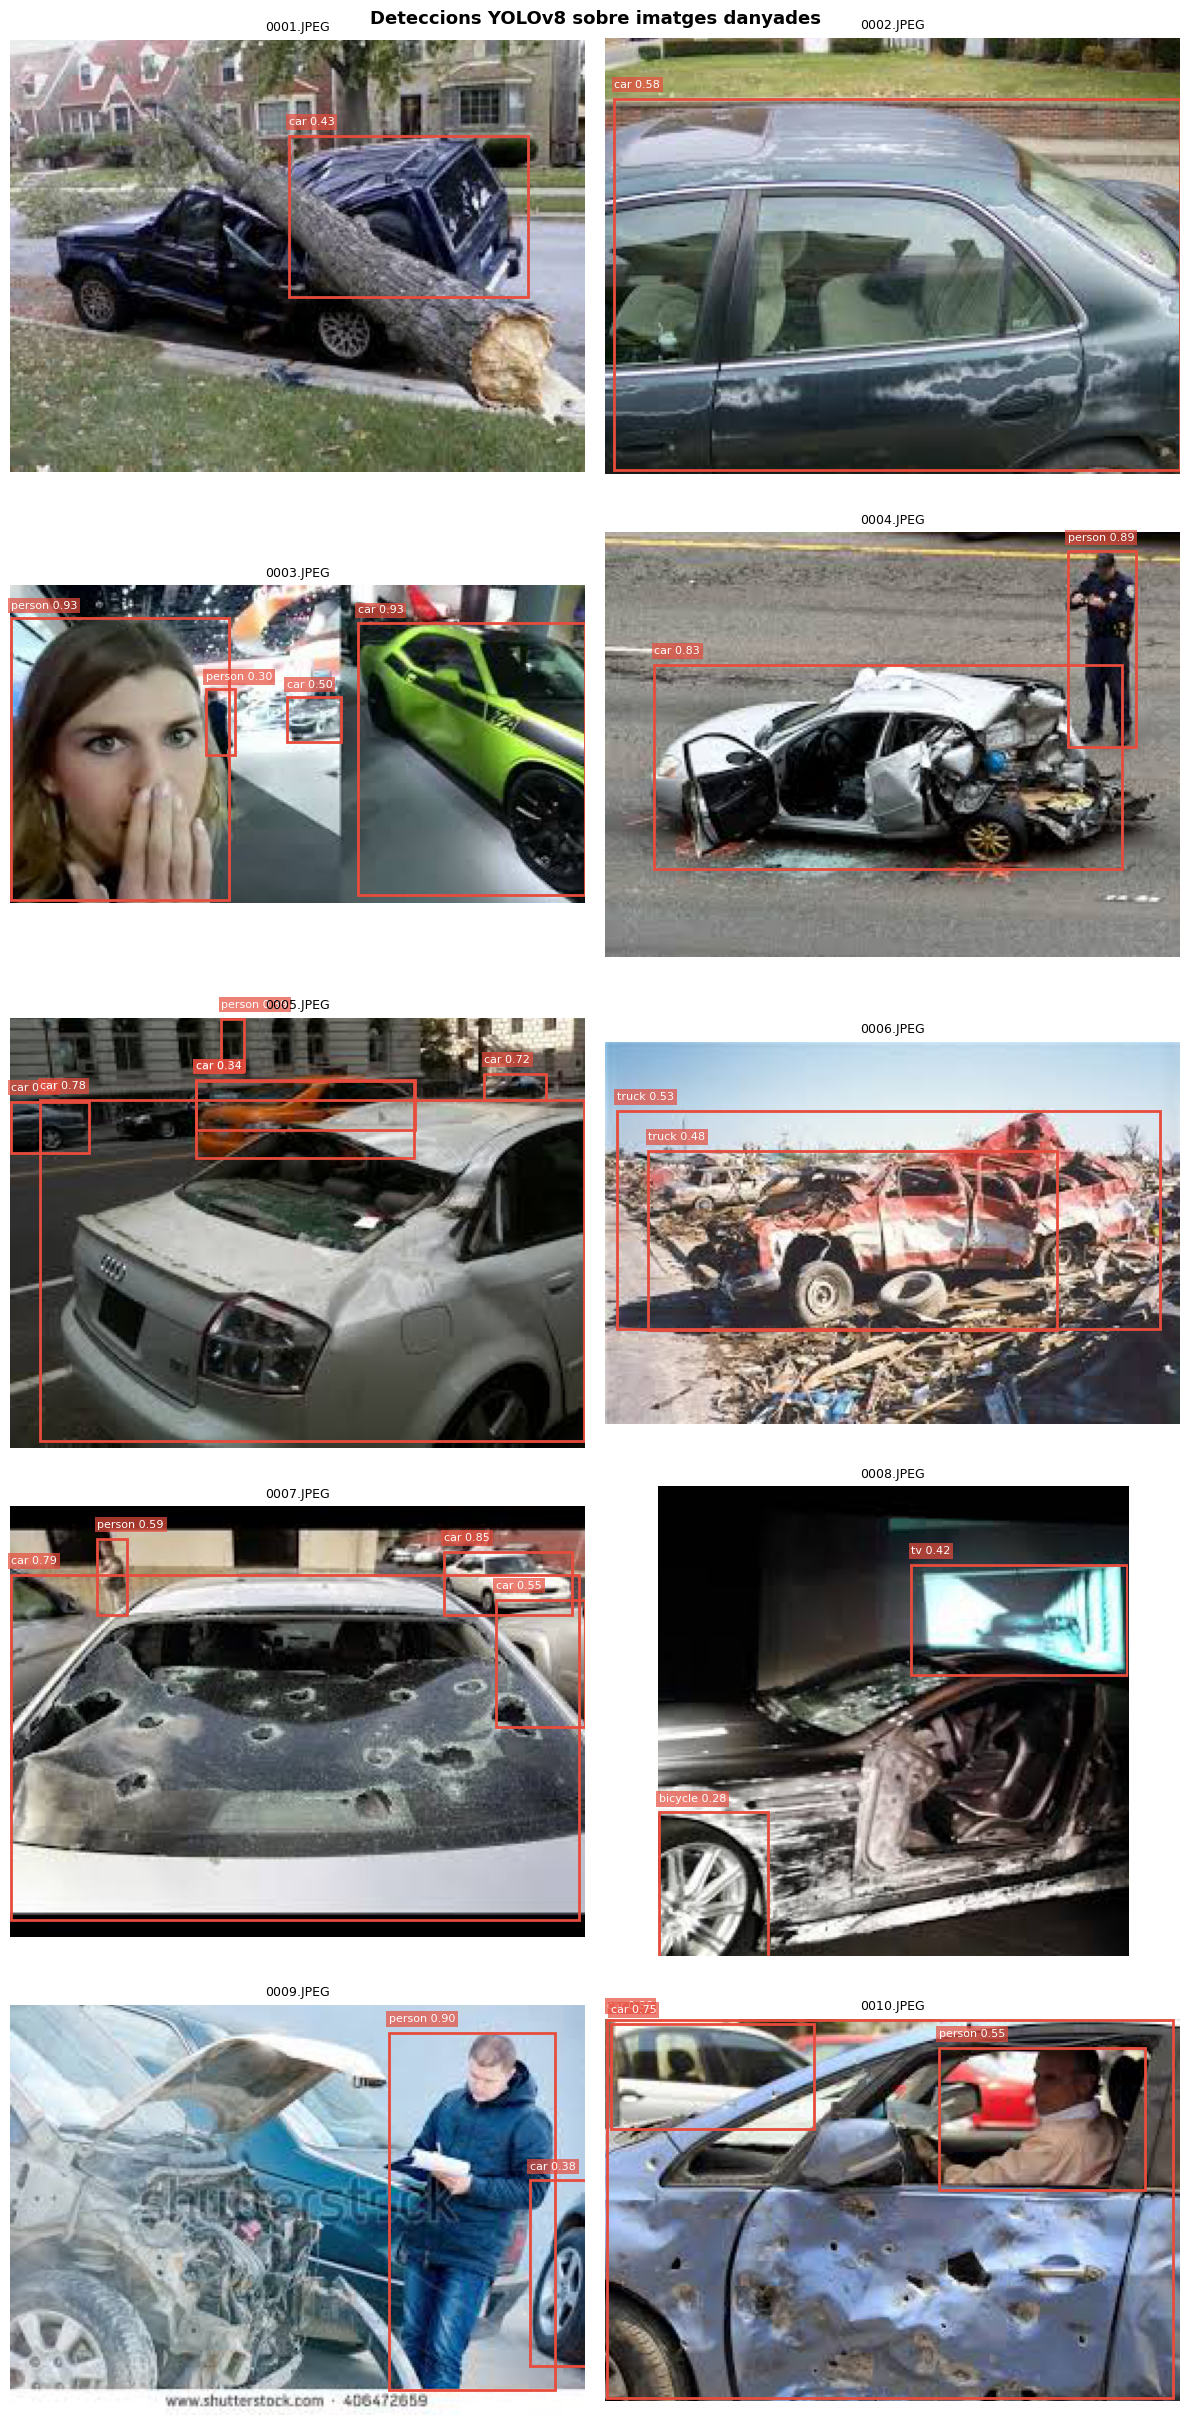

In [14]:
if not SKIP_YOLO:
    try:
        from ultralytics import YOLO
        yolo = YOLO('yolov8n.pt')
        sample_paths = damaged_paths[:YOLO_SAMPLES]

        cols = 2
        rows = (len(sample_paths) + 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(12, 5*rows))
        axes = np.array(axes).flatten()

        for idx, img_path in enumerate(sample_paths):
            results = yolo(str(img_path), verbose=False)[0]
            ax = axes[idx]
            ax.imshow(Image.open(img_path).convert('RGB'))
            for box in results.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf  = box.conf[0].item()
                label = f"{results.names[int(box.cls[0])]} {conf:.2f}"
                ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                             linewidth=2, edgecolor='#e74c3c', facecolor='none'))
                ax.text(x1, y1-5, label, color='white', fontsize=8,
                        bbox=dict(facecolor='#e74c3c', alpha=0.7, pad=2, edgecolor='none'))
            ax.set_title(img_path.name, fontsize=9)
            ax.axis('off')

        for j in range(idx+1, len(axes)):
            axes[j].axis('off')

        plt.suptitle('Deteccions YOLOv8 sobre imatges danyades', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'yolo_detections.png', dpi=150, bbox_inches='tight')
        plt.show()

    except ImportError:
        print('YOLOv8 no instal·lat. Fes:  pip install ultralytics')
else:
    print('Fase YOLO saltada (SKIP_YOLO=True).')